In [25]:
#!pip install scanpy
import scanpy as sc
import os
import glob
import pandas as pd



luca = sc.read_h5ad("/home/ebrukocakaya/20250721_luca_download.h5ad")
luca

AnnData object with n_obs × n_vars = 1283972 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'm

In [24]:
luca.var

NameError: name 'luca' is not defined

In [3]:
luca.obs.groupby('ann_fine').size()

/tmp/ipykernel_1990495/3286594381.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  luca.obs.groupby('ann_fine').size()


ann_fine
Alveolar cell type 1                 7230
Alveolar cell type 2                47999
B cell                              68430
B cell dividing                       577
Cancer cells                        91528
Ciliated                            12205
Club                                 2689
DC mature                            2406
Endothelial cell arterial            3793
Endothelial cell capillary          16898
Endothelial cell lymphatic           5887
Endothelial cell venous             20843
Fibroblast adventitial               5629
Fibroblast alveolar                  4663
Fibroblast peribronchial             5744
Macrophage                         114381
Macrophage alveolar                147293
Mast cell                           19838
Mesothelial                           602
Monocyte classical                  86641
Monocyte non-classical               9189
Myeloid dividing                     7663
NK cell                             73830
NK cell dividing         

In [3]:
luca.obs

,sample,uicc_stage,ever_smoker,age,donor_id,origin,dataset,ann_fine,cell_type_predicted,doublet_status,...,tissue_type,EGFR_mutation,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
001C_AAACCTGCATCGGGTC-0,Adams_Kaminski_2020_001C,non-cancer,no,22.0,Adams_Kaminski_2020_001C,normal,Adams_Kaminski_2020,Monocyte non-classical,Monocyte,singlet,...,tissue,NaN,non-classical monocyte,10x 3' v2,normal,male,lung,unknown,22-year-old stage,re{$hj#%bw
001C_AAACCTGTCAACACCA-0,Adams_Kaminski_2020_001C,non-cancer,no,22.0,Adams_Kaminski_2020_001C,normal,Adams_Kaminski_2020,Macrophage alveolar,Macrophage,singlet,...,tissue,NaN,alveolar macrophage,10x 3' v2,normal,male,lung,unknown,22-year-old stage,mr6dH!~~)J
001C_AAACGGGAGACTAAGT-0,Adams_Kaminski_2020_001C,non-cancer,no,22.0,Adams_Kaminski_2020_001C,normal,Adams_Kaminski_2020,Endothelial cell lymphatic,Endothelial cell,singlet,...,tissue,NaN,endothelial cell of lymphatic vessel,10x 3' v2,normal,male,lung,unknown,22-year-old stage,CCVy?k_Hpi
001C_AAACGGGAGGCTCATT-0,Adams_Kaminski_2020_001C,non-cancer,no,22.0,Adams_Kaminski_2020_001C,normal,Adams_Kaminski_2020,Macrophage,Macrophage,singlet,...,tissue,NaN,macrophage,10x 3' v2,normal,male,lung,unknown,22-year-old stage,dICnrm?v}Y
001C_AAACGGGAGGGAACGG-0,Adams_Kaminski_2020_001C,non-cancer,no,22.0,Adams_Kaminski_2020_001C,normal,Adams_Kaminski_2020,Monocyte classical,Monocyte,singlet,...,tissue,NaN,classical monocyte,10x 3' v2,normal,male,lung,unknown,22-year-old stage,5Vz7FxxH^r
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACATCTATGG-1-38-8,Leader_Merad_2021_414,II,no,64.0,Leader_Merad_2021_729,tumor_primary,Leader_Merad_2021_10x_3p_v2_beads,Macrophage,NaN,singlet,...,tissue,NaN,macrophage,10x 3' v2,lung adenocarcinoma,female,lung,unknown,64-year-old stage,A#pCiVqT8Z
TTTGTCACATGTTGAC-1-38-8,Leader_Merad_2021_414,II,no,64.0,Leader_Merad_2021_729,tumor_primary,Leader_Merad_2021_10x_3p_v2_beads,Monocyte classical,NaN,singlet,...,tissue,NaN,classical monocyte,10x 3' v2,lung adenocarcinoma,female,lung,unknown,64-year-old stage,C{<h|YtC)P
TTTGTCAGTGTTGGGA-1-38-8,Leader_Merad_2021_414,II,no,64.0,Leader_Merad_2021_729,tumor_primary,Leader_Merad_2021_10x_3p_v2_beads,Macrophage,NaN,singlet,...,tissue,NaN,macrophage,10x 3' v2,lung adenocarcinoma,female,lung,unknown,64-year-old stage,lpE0#RH%^*
TTTGTCATCAGTTTGG-1-38-8,Leader_Merad_2021_414,II,no,64.0,Leader_Merad_2021_729,tumor_primary,Leader_Merad_2021_10x_3p_v2_beads,T cell regulatory,NaN,singlet,...,tissue,NaN,regulatory T cell,10x 3' v2,lung adenocarcinoma,female,lung,unknown,64-year-old stage,)854XipjN$


In [43]:
target_labels = [
    "Anti inflammatory alveolar macrophage",
    "Anti inflammatory macrophage",
    "Cycling anti inflammatory alveolar macrophage",
    "Cycling anti inflammatory macrophage",
    "Elicited macrophage",
    "Macrophage",
    "Macrophage alveolar",
    "Macrophage lung",
    "Macrophage monocyte",
    "Pro inflammatory macrophage",
    "Stab1 anti inflammatory macrophage",
    "Monocyte classical",
    "Monocyte non classical",
    "Myeloid dividing"
]

mask = subset_batch.obs['ann_fine'].isin(target_labels)
subset_fin = subset_batch[mask].copy()
subset_fin.obs.groupby('ann_fine').size()

subset_fin





/tmp/ipykernel_2020275/1125957915.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset_fin.obs.groupby('ann_fine').size()


AnnData object with n_obs × n_vars = 4318 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mean

In [37]:
#luca.obs
subset_batch.obs.groupby('donor_id').size()
import os
import sys

# Start with the main object
total = sys.getsizeof(subset_batch)

# Convert to readable format
size_mb = total / (1024 ** 2)
size_gb = total / (1024 ** 3)
print(f"Estimated in-memory size: {size_mb:.2f} MB ({size_gb:.2f} GB)")


Estimated in-memory size: 968.01 MB (0.95 GB)


/tmp/ipykernel_2020275/347432383.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset_batch.obs.groupby('donor_id').size()


In [27]:

batch_name = "Laughney_Massague_2020"
subset_batch = luca[luca.obs['dataset'] == batch_name].copy()
subset_batch.obs


,sample,uicc_stage,ever_smoker,age,donor_id,origin,dataset,ann_fine,cell_type_predicted,doublet_status,...,tissue_type,EGFR_mutation,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
120703409633700_0-10,Laughney_Massague_2020_GSM3516672,I,yes,NaN,Laughney_Massague_2020_LX682,tumor_primary,Laughney_Massague_2020,T cell CD8 effector memory,T cell CD8,singlet,...,tissue,not mutated,"CD8-positive, alpha-beta T cell",10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,*gp^nKxVr#
120703423507166_0-10,Laughney_Massague_2020_GSM3516672,I,yes,NaN,Laughney_Massague_2020_LX682,tumor_primary,Laughney_Massague_2020,NK cell,NK cell,singlet,...,tissue,not mutated,natural killer cell,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,M~0t`zj_fm
120703423561070_0-10,Laughney_Massague_2020_GSM3516672,I,yes,NaN,Laughney_Massague_2020_LX682,tumor_primary,Laughney_Massague_2020,T cell CD8 terminally exhausted,T cell CD8,singlet,...,tissue,not mutated,"CD8-positive, alpha-beta T cell",10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,iEN$%nf((I
120703436306869_0-10,Laughney_Massague_2020_GSM3516672,I,yes,NaN,Laughney_Massague_2020_LX682,tumor_primary,Laughney_Massague_2020,B cell,B cell,singlet,...,tissue,not mutated,B cell,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,dZrjKgUYQ+
120703455743211_0-10,Laughney_Massague_2020_GSM3516672,I,yes,NaN,Laughney_Massague_2020_LX682,tumor_primary,Laughney_Massague_2020,T cell CD8 activated,T cell CD4,singlet,...,tissue,not mutated,"CD8-positive, alpha-beta T cell",10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,Cf2xk^6yF?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241114576481206_16-10,Laughney_Massague_2020_GSM3516673,I,yes,NaN,Laughney_Massague_2020_LX682,normal_adjacent,Laughney_Massague_2020,Macrophage alveolar,Macrophage,singlet,...,tissue,not mutated,alveolar macrophage,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,w$8GSSB={=
241114577287974_16-10,Laughney_Massague_2020_GSM3516673,I,yes,NaN,Laughney_Massague_2020_LX682,normal_adjacent,Laughney_Massague_2020,Macrophage,Macrophage,singlet,...,tissue,not mutated,macrophage,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,9)+cy)xbq8
241114589031734_16-10,Laughney_Massague_2020_GSM3516673,I,yes,NaN,Laughney_Massague_2020_LX682,normal_adjacent,Laughney_Massague_2020,Macrophage alveolar,Macrophage,singlet,...,tissue,not mutated,alveolar macrophage,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,S@d%77sJ*C
241114589096668_16-10,Laughney_Massague_2020_GSM3516673,I,yes,NaN,Laughney_Massague_2020_LX682,normal_adjacent,Laughney_Massague_2020,Macrophage,Macrophage,singlet,...,tissue,not mutated,macrophage,10x 3' v2,lung adenocarcinoma,unknown,lung,unknown,unknown,6ojqyF<U;f


In [10]:
#merged = sc.read_h5ad("/mnt/lun3/processed/ElifDuymaz/scq/merged.h5ad")
merged.obs.groupby('sample').size()
merged

/tmp/ipykernel_2020275/2216627594.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.obs.groupby('sample').size()


AnnData object with n_obs × n_vars = 6721 × 26108
    obs: 'sample', 'fastq_1', 'fastq_2', 'batch', 'label', 'sample_original', 'n_counts', 'n_genes', 'scvi-0.5_leiden', 'scvi-1.0_leiden'
    var: 'n_cells'
    obsm: 'X_scvi_umap'
    layers: 'ambient', 'counts', 'log1p'

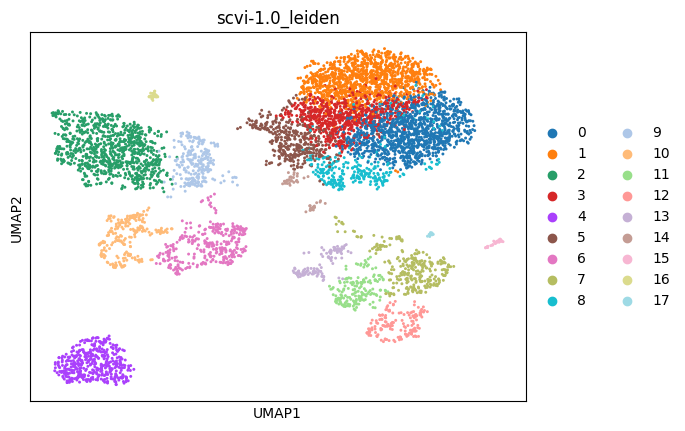

In [13]:
merged.obsm['X_umap'] = merged.obsm['X_scvi_umap']
sc.pl.umap(merged, color='scvi-1.0_leiden')


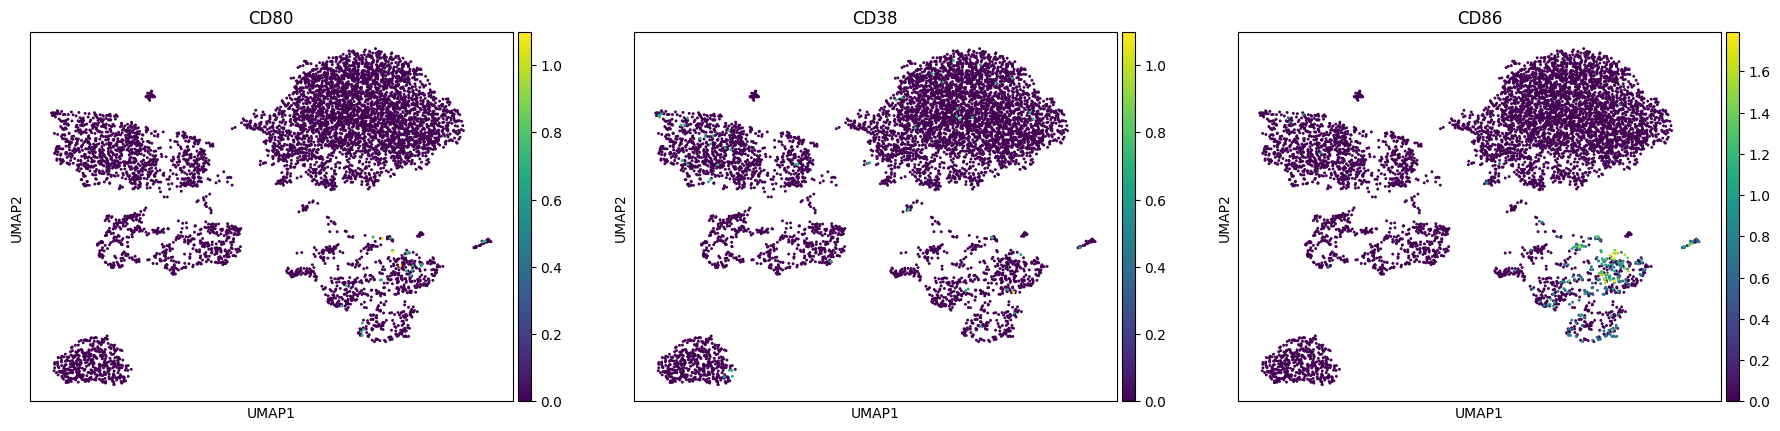

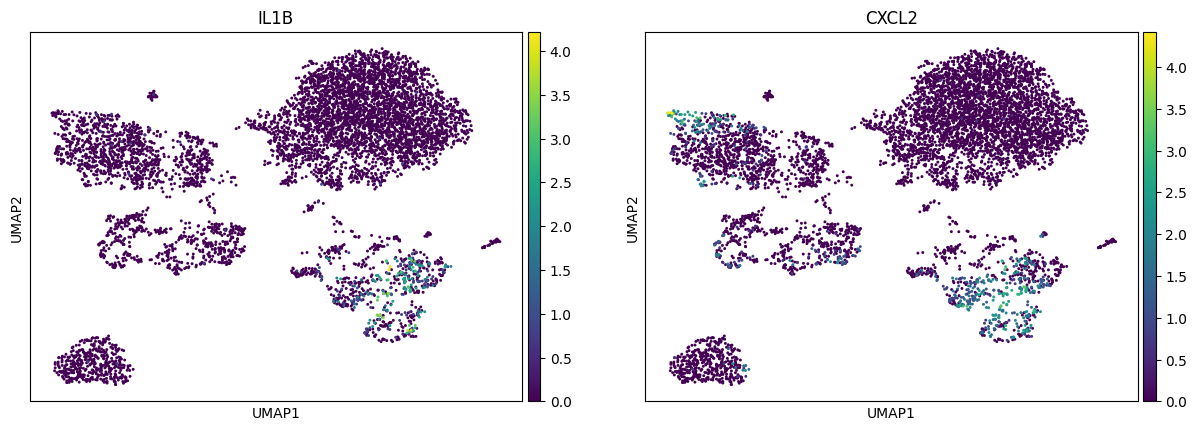

In [19]:
#merged.obs.groupby('batch').size()
#M1:
sc.pl.umap(merged, color=["CD80","CD38","CD86"])
sc.pl.umap(merged, color=["IL1B","CXCL2"])


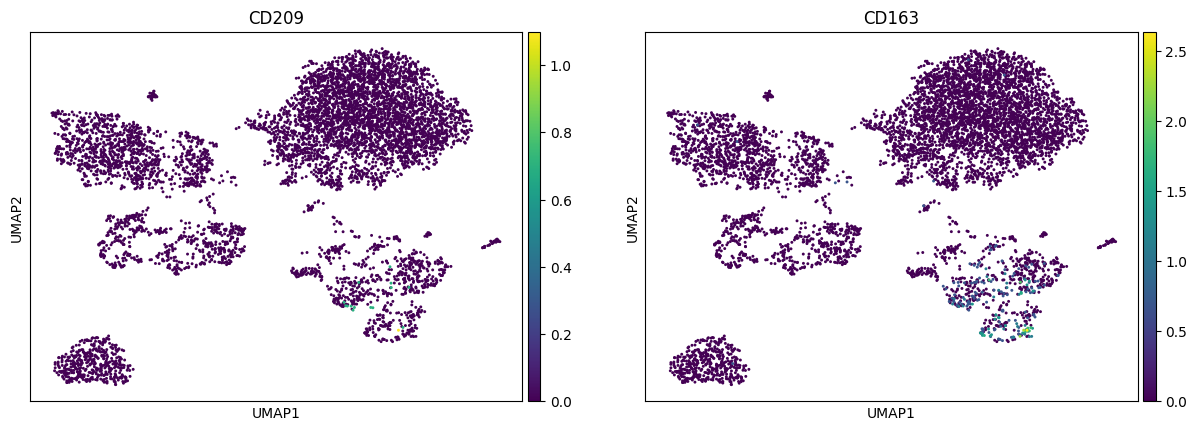

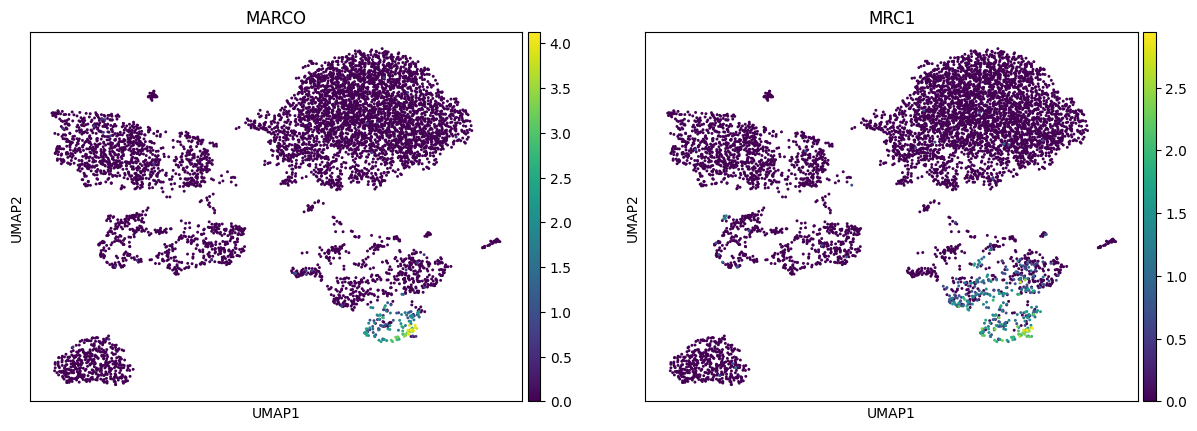

In [21]:
#merged.obs.groupby('batch').size()
#M2:
sc.pl.umap(merged, color=["CD209","CD163"])
sc.pl.umap(merged, color=["MARCO","MRC1"])

In [41]:
#save subset_bat
#subset_batch.write_h5ad("/home/ebrukocakaya/202507_luaghney_luca_subset.h5ad")

import scanpy as sc
abc = sc.read_h5ad("/home/ebrukocakaya/202507_luaghney_luca_subset.h5ad")
abc

AnnData object with n_obs × n_vars = 26403 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mea

In [46]:
#subset_fin.write_h5ad("/home/ebrukocakaya/202507_luaghney_luca_macs_subset.h5ad")


#subset_batch.write_h5ad("/home/ebrukocakaya/202507_luaghney_luca_subset.h5ad")

abc = sc.read_h5ad("/home/ebrukocakaya/202507_luaghney_luca_macs_subset.h5ad")
abc


AnnData object with n_obs × n_vars = 4318 × 17797
    obs: 'sample', 'uicc_stage', 'ever_smoker', 'age', 'donor_id', 'origin', 'dataset', 'ann_fine', 'cell_type_predicted', 'doublet_status', 'leiden', 'n_genes_by_counts', 'total_counts', 'total_counts_mito', 'pct_counts_mito', 'ann_coarse', 'cell_type_tumor', 'tumor_stage', 'TP53_mutation', 'ALK_mutation', 'BRAF_mutation', 'ERBB2_mutation', 'KRAS_mutation', 'ROS_mutation', 'origin_fine', 'study', 'platform', 'cell_type_major', 'cell_type_neutro', 'cell_type_neutro_coarse', 'suspension_type', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'EGFR_mutation', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'is_highly_variable', 'mito', 'n_cells_by_counts', 'mean